# 숫자가 말해주지 않는 'Why'를 읽는 법 — 정성 데이터 분석 실습

커머스 상품 구매 리뷰에서 별점 5점(매우 만족)과 1점(매우 불만족) 리뷰가 **서로 어떤 말로 쓰여 있는지**를
여러 방법으로 비교합니다. 단어를 세고(빈도), 두 집단을 가르는 말을 찾고(가중치), 말과 말의 관계를
그리고(네트워크), 주제로 묶은(토픽) 다음, 추상화된 숫자에서 다시 원문으로 내려와 확인하고,
마지막으로 5점 리뷰에서 미처 몰랐던 강점을 찾아내는 흐름입니다.

| 본문 장 | 실습 절 | 답하는 질문 | 도구 |
| :-- | :-- | :-- | :-- |
| 1. 텍스트 빈도 분석 | 실습 1·2 | 무엇이 많이 나오나 | `kiwipiepy`, `Counter`, `wordcloud` |
| 2. 텍스트 가중치 분석 | 실습 3 | 무엇이 두 집단을 가르나 | 유니크 키워드, TF-IDF, 로그 오즈비 |
| 3. 단어 연관성·네트워크 | 실습 4 | 무엇과 함께 나오나 | `networkx`, PMI, 커뮤니티 |
| 4. 주제 및 의미 분석 | 실습 5 | 어떤 주제가 흐르나 | 토픽 모델링(LDA) |
| 5. 원문 맥락 확인 | 실습 6 | 그 신호가 진짜인가 | KWIC, 대표 리뷰 |
| 6. 긍정 리뷰의 발견 | 실습 7 | 미처 몰랐던 강점은 | 5점 동시출현 네트워크 |

이론 설명은 책 본문에 있으니, 이 노트북에서는 셀을 위에서 아래로 실행하며 결과를 확인하시면 됩니다.
실습 절 번호는 책의 '실습 (Python, SQL)' 절 구성과 동일하게 맞췄습니다(본문 장 번호와는 위 표처럼 대응합니다).

> 예시 데이터(`data/reviews.csv`)는 `generate_data.py`로 만든 합성 리뷰입니다. 1점에는 '환불·연락'
> 같은 CS 불만이, 5점에는 '원룸·강아지·청소' 같은 쓰임새·고객 맥락이 더 자주 나오도록 심어
> 두었습니다. 아래 분석이 그 차이를 실제로 복원해 내는지 확인해 보세요.

## 0. 실습용 데이터 준비

아래 셀은 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서
`python generate_data.py` 를 실행해 예시 데이터(`data/reviews.csv`)를 만들어 주세요.

의존성은 이미 설치돼 있으면 빠르게 넘어갑니다.

In [1]:
# 의존성 설치 
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 실습용 데이터 환경 구성
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 네트워크 그래프의 한글 라벨이 깨지지 않도록 한글 폰트를 지정합니다.
# [내 데이터 적용] 기본 폰트가 없으면 아래 분기의 폰트명을 바꿉니다.
import sys
if sys.platform.startswith("win"):
    plt.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 맑은 고딕
elif sys.platform == "darwin":
    plt.rcParams["font.family"] = "AppleGothic"  # macOS
else:
    plt.rcParams["font.family"] = "NanumGothic"  # 리눅스(나눔고딕 설치 필요)
plt.rcParams["axes.unicode_minus"] = False

# 만족(초록)/불만(빨강) 팔레트 — 변별 막대·네트워크 시각화에 일관되게 씁니다.
POS_GREEN, NEG_RED, MUTED = "#2E9E6B", "#E5564E", "#C3CAD2"

### 리뷰 데이터 살펴보기

먼저 원천 데이터를 살펴봅니다. 리뷰 한 건이 한 행이고, 별점(`rating`)과 리뷰 본문(`text`)을
가집니다. 이 중 5점(매우 만족)과 1점(매우 불만족)만 골라 두 집단(`pos`, `neg`)으로 나눠
이후 분석의 입력으로 씁니다. (작성일 `created_at`은 실습 5의 토픽 시계열에서만 씁니다.)
실제 운영 리뷰 데이터가 있다면 그대로 사용해도 좋고, 없다면 `generate_data.py`로 만든 예시 데이터를 활용하면 됩니다.

이제 리뷰 데이터를 불러와 비교할 두 집단(5점 vs 1점)을 정의합니다.

In [3]:
# [내 데이터 적용] 경로를 내 리뷰 CSV로, rating·text도 실제 컬럼명에 맞춥니다.
reviews = pd.read_csv("data/reviews.csv")

# [내 데이터 적용] '비교할 두 집단'을 정의하는 곳입니다. 별점 5 vs 1이 아니어도
#   됩니다 — 4점 이상 vs 2점 이하, 자사 vs 경쟁사, 이탈 vs 잔존처럼 바꾸면
#   이후 분석(빈도·변별 키워드·네트워크)이 그대로 그 두 집단 비교에 적용됩니다.
# 아래 두 줄만 바꾸면 이후 분석 축 전체가 따라 바뀝니다.
GROUP_A = reviews["rating"] == 5    # 매우 만족
GROUP_B = reviews["rating"] == 1    # 매우 불만족
pos = reviews[GROUP_A]["text"]
neg = reviews[GROUP_B]["text"]
print("전체:", len(reviews), "| 5점:", len(pos), "| 1점:", len(neg))
reviews.head()

전체: 1020 | 5점: 450 | 1점: 450


,review_id,product_id,rating,text,created_at
0,1,P-1006,5,사이즈가 정사이즈고 배송이 하루 만에 오고 강력 추천합니다 강아지 털이 안 붙어서 ...,2024-06-06
1,2,P-1033,1,배송이 하세월이고 재질이 거칠고 가격이 비싼데 별로고 환불 요청에 연락이 안 되고 ...,2024-04-22
2,3,P-1021,1,색상이 이상하고 재질이 부실하고 환불 문의에 연락이 두절이고 두 번 다시 안 사요...,2024-03-29
3,4,P-1015,5,가성비가 훌륭하고 재구매 의사 있어요 재질이 튼튼하고 사이즈가 넉넉하고 자취방이 좁...,2024-01-24
4,5,P-1002,1,색상이 이상하고 사이즈가 안 맞고 두 번 다시 안 사요ㅠㅠ,2024-04-11


## 실습 1. 전처리와 형태소 분석

정성 데이터 분석의 가장 기초는 단어 빈도를 세는 것입니다. 다만 그 전에 전처리가 필요합니다 —
한국어는 교착어라 '배송이/배송도/배송은'을 형태소로 쪼개야 같은 단어로 모이기 때문입니다.

`kiwipiepy`로 체언(명사)과 용언(동사·형용사 원형)만 남기고, 너무 흔한 불용어는 제거합니다.

In [4]:
from kiwipiepy import Kiwi
kiwi = Kiwi()
# [내 데이터 적용] "총알배송"처럼 사전에 없는 도메인 신조어가 엉뚱하게 쪼개지면
#   kiwi.add_user_word("총알배송", "NNG") 로 등록하면 한 단어로 잡힙니다.

# 흔해서 정보가 없는 단어들 — 결과를 보다가 계속 추가합니다 [내 데이터 적용]
STOPWORDS = {"상품", "제품", "구매", "주문", "정말", "너무", "그냥"}

def clean(text):
    # 한글/영문/숫자/공백만 남긴다
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

이 환경 위에서, 부정어를 살려 주는 토크나이저를 정의하고 두 집단을 토큰화합니다.

In [5]:
NEG_BEFORE = {"안", "못"}     # 용언 앞의 부정 부사
NEG_AFTER  = {"않", "못"}     # 용언 뒤의 부정 보조용언

def tokenize(text):
    """체언/용언만 토큰으로 뽑는다. 부정어(안/못/않)가 붙은 용언은
    '~다(부정)'으로 표시해 '연락이 안 되다'가 '되다'로 뭉개지지 않게 한다."""
    toks  = list(kiwi.tokenize(clean(text)))
    forms = [t.form for t in toks]
    tokens = []
    for i, t in enumerate(toks):
        if t.tag in ("NNG", "NNP") and len(t.form) >= 2:   # 체언(2글자 이상)
            word = t.form
        elif t.tag in ("VV", "VA"):  # 용언 → 원형 복원(+부정 표시)
            neg = (i > 0 and forms[i-1] in NEG_BEFORE) \
                  or any(f in NEG_AFTER for f in forms[i+1:i+3])
            word = t.form + "다" + ("(부정)" if neg else "")
        else:
            continue
        if word not in STOPWORDS:
            tokens.append(word)
    return tokens
pos_tokens = [w for text in pos for w in tokenize(text)]
neg_tokens = [w for text in neg for w in tokenize(text)]
print("5점 예시:", tokenize(pos.iloc[0]))
print("1점 예시:", tokenize(neg.iloc[0]))

5점 예시: ['사이즈', '사이즈', '배송', '하루', '오다', '강력', '추천', '강아지', '붙다(부정)', '반려동물', '키우다', '추천', '디자인', '고급']
1점 예시: ['배송', '세월', '재질', '거칠다', '가격', '비싸다', '환불', '요청', '연락', '되다(부정)']


## 실습 2. 텍스트 빈도 분석

형태소로 쪼갠 단어의 빈도를 셉니다. 표로 상위 키워드를 보고, 워드클라우드로도 시각화합니다.
단어를 빈도에 비례한 크기로 흩뿌리되 글자는 모두 가로로 두고 다채로운 팔레트로 칠합니다.
다만 5점·1점 워드클라우드를 나란히 놓으면 '사이즈·재질·디자인'처럼 양쪽 공통어가 커서 두 집단을 잘
구별해 주지는 못합니다. 이 한계가 다음 '가중치 분석'의 출발점이 됩니다.

In [6]:
pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

# 상위 빈도 단어를 표로 정리한다 (단어 · 등장 횟수)
def freq_terms(freq, n=15):
    return [f"{w}  ·  {c}회" for w, c in freq.most_common(n)]

freq_top = pd.DataFrame(
    {"5★ 상위 (단어 · 빈도)": freq_terms(pos_freq),
     "1★ 상위 (단어 · 빈도)": freq_terms(neg_freq)},
    index=pd.RangeIndex(1, 16, name="순위"),
)
freq_top.style.set_caption("단어 빈도 기준 집단별 상위 키워드") \
              .set_properties(**{"text-align": "left"})

,5★ 상위 (단어 · 빈도),1★ 상위 (단어 · 빈도)
순위,,
1,사이즈 · 249회,환불 · 355회
2,좋다 · 243회,재질 · 174회
3,원룸 · 236회,사이즈 · 171회
4,공간 · 236회,포장 · 169회
5,만족 · 221회,가격 · 165회
6,재질 · 217회,디자인 · 165회
7,색상 · 207회,배송 · 162회
8,디자인 · 193회,색상 · 141회
9,키우다 · 183회,부실 · 125회


In [7]:
import zlib
from PIL import Image, ImageDraw
from wordcloud import WordCloud

# WordCloud는 폰트 파일 경로가 필요하다 — OS에 맞게 고른다 (sys는 0절 임포트)
if sys.platform.startswith("win"):
    FONT = r"C:\Windows\Fonts\malgun.ttf"  # 윈도우 맑은 고딕
elif sys.platform == "darwin":
    FONT = "/System/Library/Fonts/AppleSDGothicNeo.ttc"  # macOS
else:
    FONT = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # 리눅스(나눔고딕)

# 긍정은 파랑, 부정은 빨강 계열(변별 막대·네트워크의 초록/빨강과 구분 — 가독성).
# 같은 계열 안에서 명도를 달리해 단어마다 색이 살짝 다르게 보이도록 한다.
BLUE_PALETTE = ["#1F6FB2", "#2F80B5", "#2C82C9", "#3C93D6", "#1B9AAA",
                "#4C72B0", "#2E5E8C", "#5AA9E6", "#246EB9", "#3E8EDE"]
RED_PALETTE  = ["#C0392B", "#E5564E", "#D4496A", "#E86A5A", "#B33A3A",
                "#CC4125", "#A93226", "#E07B7B", "#D7382F", "#EB6F63"]

def make_color_func(palette):
    """단어의 crc32 해시로 색을 고른다 — 같은 단어는 항상 같은 색."""
    def color_func(word, **kwargs):
        return palette[zlib.crc32(word.encode("utf-8")) % len(palette)]
    return color_func

다음으로 단어들이 들어앉을 구름 모양 마스크를 만듭니다.

In [8]:
def cloud_mask(w=1000, h=580):
    """타원 몇 개를 겹쳐 '구름 모양' 흑백 마스크를 만든다(검정=단어 영역)."""
    img = Image.new("L", (w, h), 255)
    d = ImageDraw.Draw(img)
    def ell(cx, cy, rx, ry):
        d.ellipse([cx - rx, cy - ry, cx + rx, cy + ry], fill=0)
    ell(w * 0.50, h * 0.62, w * 0.40, h * 0.22)   # 납작한 본체(바닥)
    ell(w * 0.24, h * 0.60, w * 0.16, h * 0.15)   # 왼쪽 어깨
    ell(w * 0.76, h * 0.60, w * 0.16, h * 0.15)   # 오른쪽 어깨
    ell(w * 0.36, h * 0.40, w * 0.16, h * 0.16)   # 위쪽 봉우리들
    ell(w * 0.52, h * 0.34, w * 0.18, h * 0.18)
    ell(w * 0.66, h * 0.42, w * 0.15, h * 0.15)
    return np.array(img)

MASK = cloud_mask()

마스크 안에 두 집단의 워드클라우드를 나란히 그립니다.

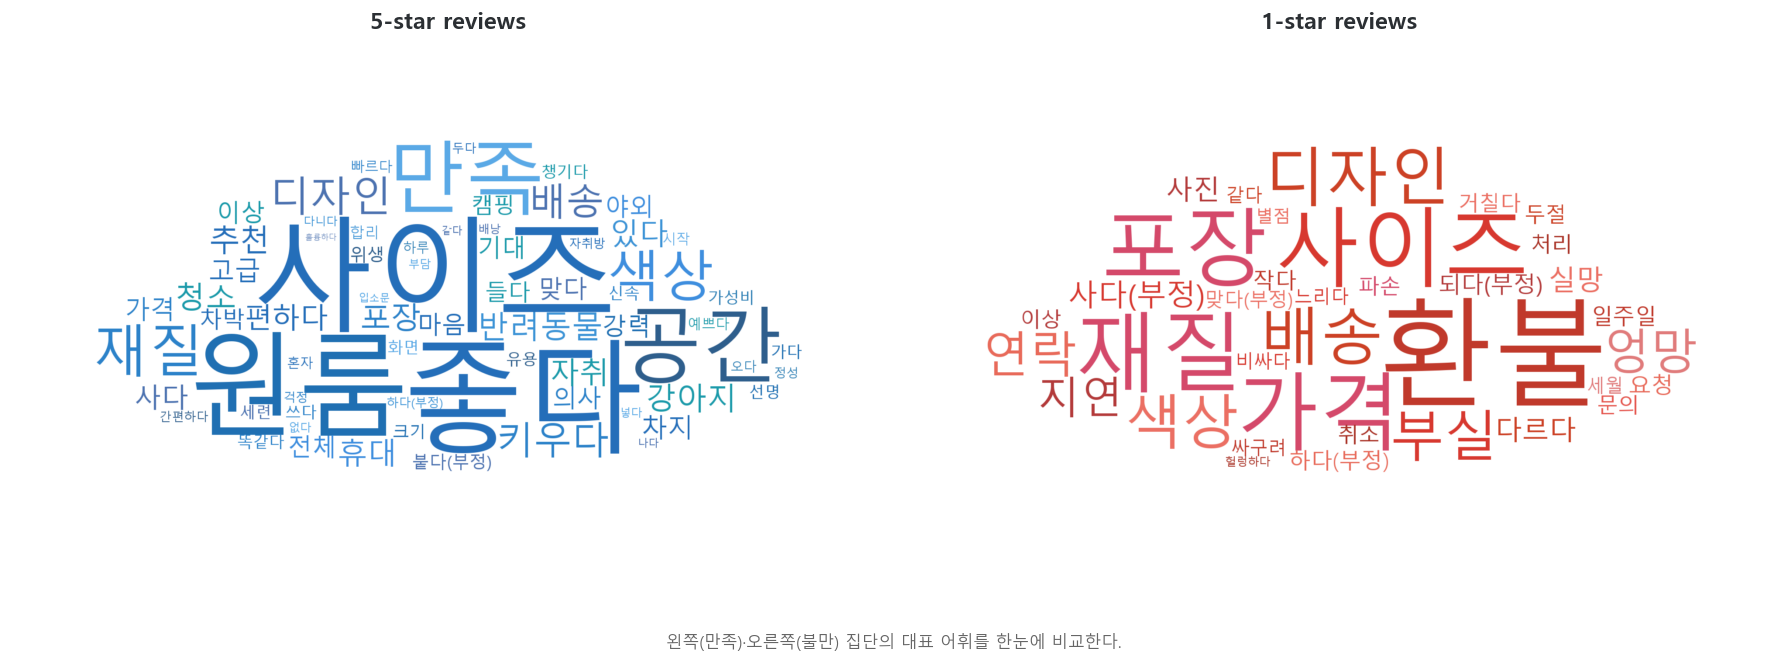

In [9]:
def draw_cloud(freq, palette):
    """구름 모양 마스크 안에 글자를 회전 없이 가로로만 그린다."""
    return WordCloud(
        font_path=FONT, mask=MASK, scale=2,
        background_color="white", color_func=make_color_func(palette),
        prefer_horizontal=1.0,  # 1.0 = 모든 글자를 가로로(세로 회전 없음)
        relative_scaling=0.5, max_words=100,
        min_font_size=9, margin=2, random_state=42,
    ).generate_from_frequencies(freq)

def show_clouds(pos_freq, neg_freq, titles):
    """긍정(왼쪽·파랑) / 부정(오른쪽·빨강) 워드클라우드를 나란히 그린다."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
    for ax, freq, title, palette in zip(
            axes, (pos_freq, neg_freq), titles, (BLUE_PALETTE, RED_PALETTE)):
        ax.imshow(draw_cloud(freq, palette), interpolation="bilinear")
        ax.set_title(title, fontsize=14, fontweight="bold",
                     color="#2b2f33", pad=12)
        ax.axis("off")
    fig.patch.set_facecolor("white")
    fig.text(0.5, 0.02, "왼쪽(만족)·오른쪽(불만) 집단의 "
             "대표 어휘를 한눈에 비교한다.",
             ha="center", fontsize=10, color="#666")
    plt.tight_layout(); plt.show()

show_clouds(pos_freq, neg_freq, ["5-star reviews", "1-star reviews"])

## 실습 3. 텍스트 가중치 분석

단순 빈도에서 벗어나, '이 단어가 특정 집단에서 얼마나 중요하거나 차별적인가'를 가중치로 봅니다.
가장 단순한 유니크 키워드부터 TF-IDF, 로그 오즈비까지 살펴봅니다.

### 3.1. 유니크 키워드 — 공통어를 빼고 차이만 남기기

양쪽 상위 키워드의 교집합을 빼면, 각 집단에만 고유한 단어만 남아 차이가 또렷해집니다.
단순하지만 꽤 효과적입니다.

5점 고유: ['좋다', '공간', '원룸', '만족', '키우다', '반려동물', '청소', '강아지', '추천', '있다']
1점 고유: ['환불', '부실', '엉망', '연락', '지연', '사다(부정)', '실망', '다르다', '사진', '되다(부정)']


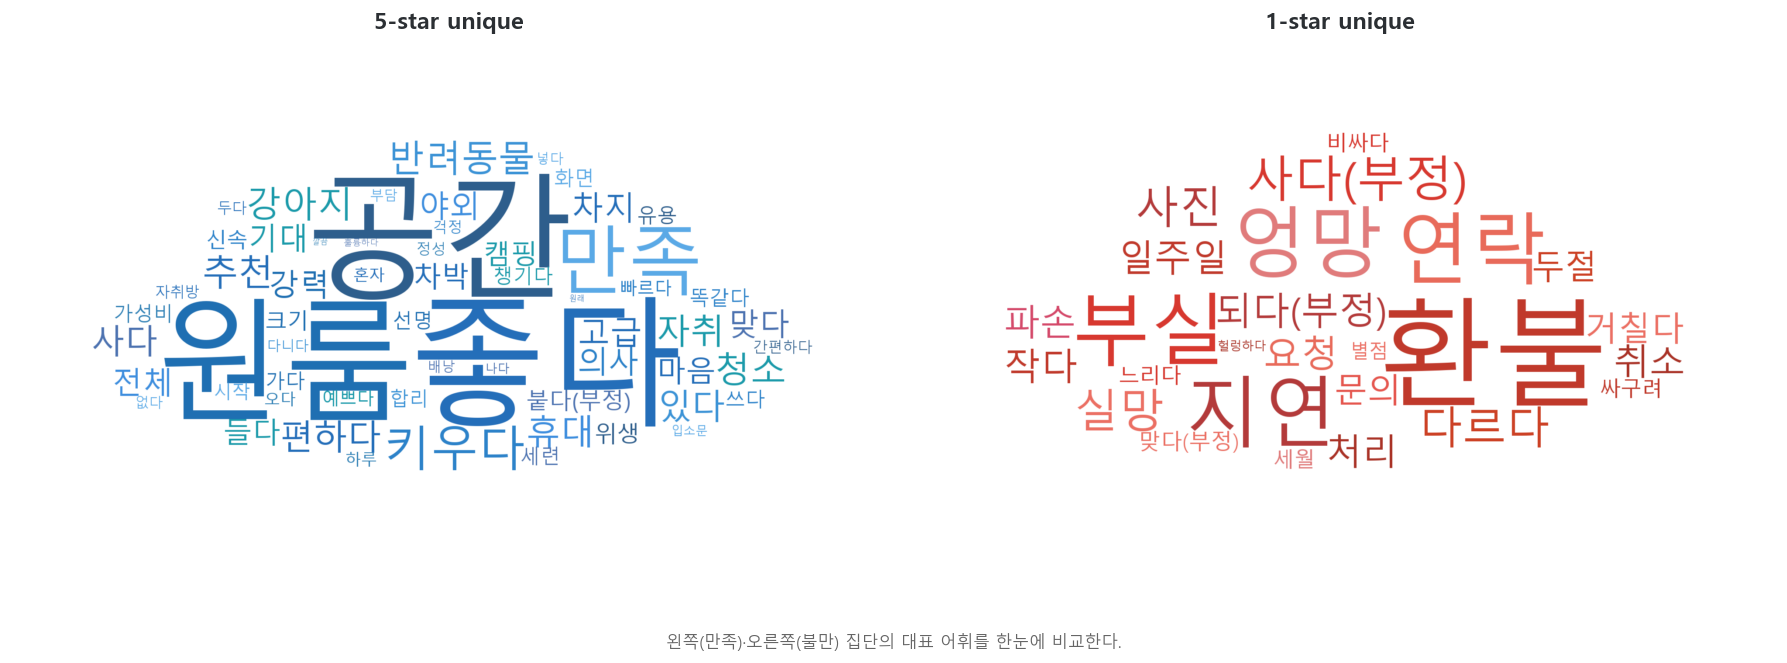

In [10]:
# [내 데이터 적용] 리뷰 수에 따라 상위 N위 컷(TOP)을 늘리거나 줄입니다.
TOP = 100
pos_top = {w for w, _ in pos_freq.most_common(TOP)}
neg_top = {w for w, _ in neg_freq.most_common(TOP)}
common = pos_top & neg_top  # 양쪽 공통(중립) 단어

pos_unique = {w: pos_freq[w] for w in pos_top - common}  # 5점에만 고유
neg_unique = {w: neg_freq[w] for w in neg_top - common}  # 1점에만 고유
print("5점 고유:", sorted(pos_unique, key=pos_unique.get, reverse=True)[:10])
print("1점 고유:", sorted(neg_unique, key=neg_unique.get, reverse=True)[:10])

show_clouds(pos_unique, neg_unique, ["5-star unique", "1-star unique"])

### 3.2. TF-IDF

한 리뷰에 자주 나오면서(TF) 전체 리뷰에는 드문(IDF) 단어일수록 점수가 높습니다. 그래서
'배송'처럼 어디에나 나오는 단어는 자동으로 가라앉고, 그 집단만의 단어가 부각됩니다.
리뷰 한 건을 문서 하나로 보고 벡터화한 뒤, 집단별 평균 TF-IDF 상위 단어를 표로 봅니다.
단순 빈도보다 '키우다·반려동물·청소·강아지' 같은 맥락 단어가 몇 계단 올라오지만, '사이즈·재질·디자인'처럼
양쪽에 다 나오는 단어는 여전히 상위에 남습니다. TF-IDF는 '한 리뷰 안에서 어떤 단어가 중요한가'를 재는
지표이지, '두 집단을 가르는 단어가 무엇인가'를 직접 재는 지표는 아니기 때문입니다 — 그 일은 다음 로그 오즈비가 합니다.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 리뷰 한 건 = 문서 하나로 벡터화 (형태소 토큰을 공백으로 이어 붙여 입력)
reviews["joined"] = reviews["text"].map(lambda t: " ".join(tokenize(t)))
# 이미 토큰화된 입력을 공백으로만 나눠 '되다(부정)' 같은 토큰을 유지한다
vec = TfidfVectorizer(token_pattern=r"(?u)[^\s]+")
X = vec.fit_transform(reviews["joined"])  # (리뷰 수 × 단어 수) 희소 행렬
vocab = np.array(vec.get_feature_names_out())

# 집단별 평균 TF-IDF — 0절에서 정의한 두 집단(GROUP_A/B)을 그대로 쓴다
pos_mean = np.asarray(X[GROUP_A.to_numpy()].mean(axis=0)).ravel()
neg_mean = np.asarray(X[GROUP_B.to_numpy()].mean(axis=0)).ravel()

def top_terms(mean_vec, n=15):
    """평균 TF-IDF가 높은 상위 n개 단어를 '단어 · 점수' 문자열로 만든다."""
    idx = mean_vec.argsort()[::-1][:n]
    return [f"{vocab[i]}  ·  {mean_vec[i]:.3f}" for i in idx]

tfidf_top = pd.DataFrame(
    {"5★ 대표 (단어 · TF-IDF)": top_terms(pos_mean),
     "1★ 대표 (단어 · TF-IDF)": top_terms(neg_mean)},
    index=pd.RangeIndex(1, 16, name="순위"),
)
tfidf_top.style.set_caption("TF-IDF 기준 집단별 상위 키워드") \
              .set_properties(**{"text-align": "left"})

,5★ 대표 (단어 · TF-IDF),1★ 대표 (단어 · TF-IDF)
순위,,
1,좋다 · 0.113,환불 · 0.204
2,만족 · 0.109,부실 · 0.106
3,원룸 · 0.103,사다(부정) · 0.103
4,공간 · 0.103,가격 · 0.103
5,키우다 · 0.091,지연 · 0.102
6,추천 · 0.089,포장 · 0.096
7,사이즈 · 0.089,디자인 · 0.096
8,반려동물 · 0.088,엉망 · 0.095
9,청소 · 0.084,사이즈 · 0.095


### 3.3. 로그 오즈비(Log-Odds Ratio)

TF-IDF가 '이 집단에서 두드러진 단어'를 본다면, 로그 오즈비는 '두 집단 중 어느 쪽으로 더
기울었나'를 직접 잽니다. 0을 기준으로 좌우로 갈라지는 다이버징 막대로, 어떤 단어가 5점(초록)·
1점(빨강) 어느 쪽을 얼마나 강하게 대표하는지 한눈에 봅니다. (Monroe et al. 2008의 정보적
디리클레 사전 가중 z-score를 씁니다.)

In [12]:
def log_odds_z(freq_a, freq_b, alpha0=1000):
    """Monroe et al.(2008) 정보적 디리클레 사전 가중 로그 오즈비(z-score).
    z>0이면 5점 쪽, z<0이면 1점 쪽. 사전(alpha0)이 희귀어 과대평가를 누른다."""
    vocab = set(freq_a) | set(freq_b)
    bg = Counter(freq_a) + Counter(freq_b)              # 배경 = 두 집단 합
    n_bg = sum(bg.values())
    na, nb = sum(freq_a.values()), sum(freq_b.values())
    out = {}
    for w in vocab:
        a_w = alpha0 * bg[w] / n_bg  # 정보적 사전(배경 빈도에 비례)
        ya, yb = freq_a.get(w, 0), freq_b.get(w, 0)
        delta = (np.log(ya + a_w) - np.log(na + alpha0 - ya - a_w)
                 - np.log(yb + a_w) + np.log(nb + alpha0 - yb - a_w))
        var = 1.0 / (ya + a_w) + 1.0 / (yb + a_w)       # 근사 분산
        out[w] = delta / np.sqrt(var)  # 분산으로 나눠 z-score로
    return out

scores = log_odds_z(pos_freq, neg_freq)

이 점수로 두 집단을 가르는 다이버징 막대를 그립니다.

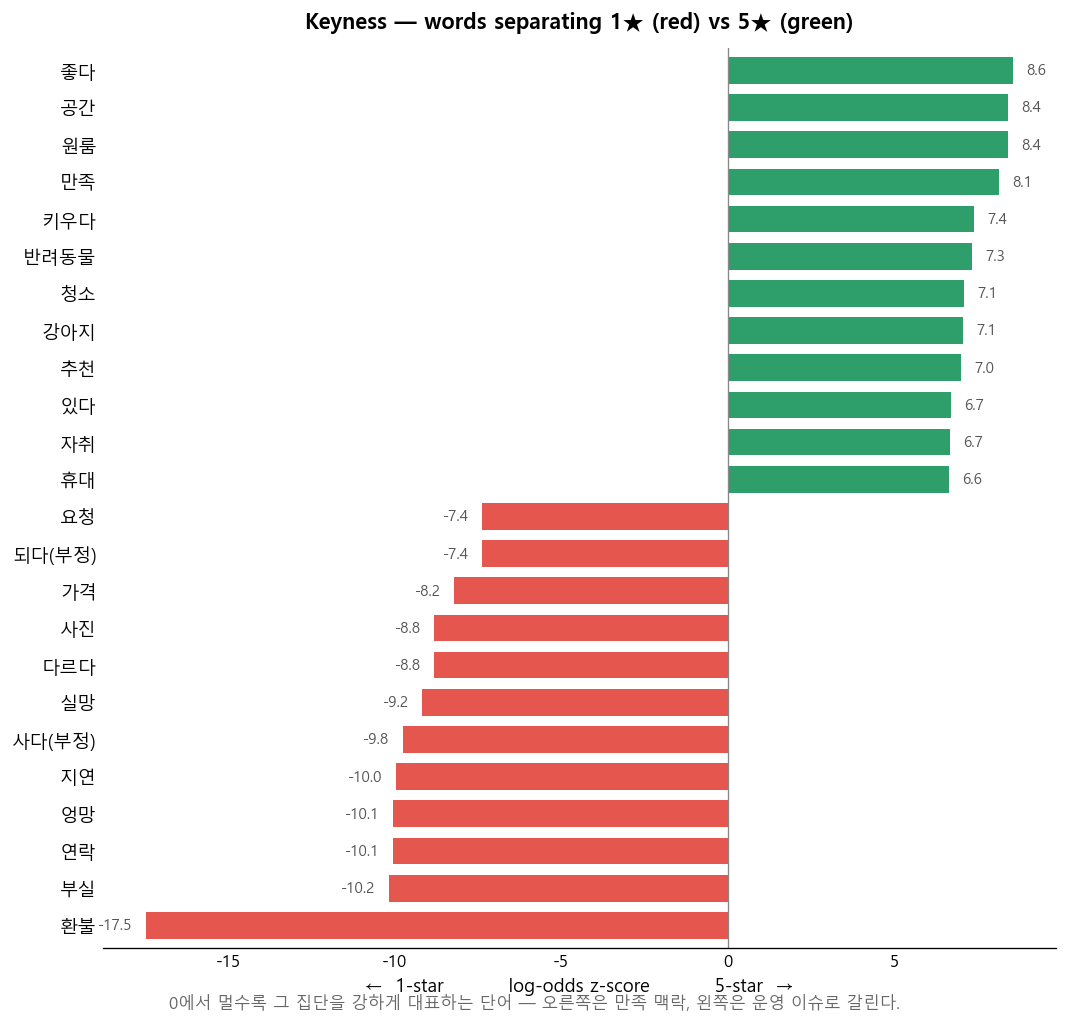

In [13]:
pos12 = sorted(scores, key=scores.get, reverse=True)[:12]  # 5점 쪽 상위 12개
neg12 = sorted(scores, key=scores.get)[:12]  # 1점 쪽 상위 12개
sel = neg12 + pos12[::-1]  # 아래=1★, 위=5★ 순으로 배치
vals = [scores[w] for w in sel]
colors = [POS_GREEN if v >= 0 else NEG_RED for v in vals]

fig, ax = plt.subplots(figsize=(9, 8.5), dpi=120)
ax.barh(range(len(sel)), vals, color=colors, height=0.72)
ax.set_yticks(range(len(sel))); ax.set_yticklabels(sel, fontsize=11)
ax.set_ylim(-0.6, len(sel) - 0.4)
ax.axvline(0, color="#888", lw=0.8)
for i, v in zip(range(len(sel)), vals):  # 막대 끝에 z값 표기
    ax.text(v + (0.4 if v >= 0 else -0.4), i, f"{v:.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9, color="#555")
ax.set_title("Keyness — words separating 1★ (red) vs 5★ (green)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("←  1-star          log-odds z-score          5-star  →",
              fontsize=11)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
fig.text(0.5, 0.005, "0에서 멀수록 그 집단을 강하게 대표하는 단어 — "
         "오른쪽은 만족 맥락, 왼쪽은 운영 이슈로 갈린다.",
         ha="center", fontsize=10, color="#666")
plt.tight_layout(); plt.show()

## 실습 4. 단어 연관성 및 네트워크 분석

개별 단어의 중요도를 넘어, 단어와 단어가 어떻게 연결되어 문맥을 이루는지 봅니다.

### 4.1. 바이그램(Bigram)

단어 하나로는 '사이즈'가 좋다는 건지 작다는 건지 알 수 없습니다. 연속한 두 단어의 짝(바이그램)을
세면, '사이즈 → 작다'처럼 단어 하나로는 보이지 않던 맥락이 드러납니다.

In [14]:
def bigrams_of(texts):
    """각 리뷰에서 '연속한 두 단어(바이그램)'를 모두 뽑는다.
    zip(toks, toks[1:])는 (1번째,2번째),(2번째,3번째)... 식으로 이웃한 쌍을 만든다."""
    rows = []
    for text in texts:
        toks = tokenize(text)
        for a, b in zip(toks, toks[1:]):   # 바로 옆에 붙어 나온 두 토큰
            rows.append((a, b))
    return pd.DataFrame(rows, columns=["word1", "word2"])

# 1점 리뷰에서 가장 자주 붙어 나온 단어 쌍 상위 15개
neg_bigrams = bigrams_of(neg).value_counts().reset_index(name="n")
neg_bigrams.head(15)

,word1,word2,n
0,사진,다르다,94
1,환불,요청,66
2,요청,연락,66
3,연락,되다(부정),66
4,재질,부실,66
5,포장,엉망,63
6,가격,하다(부정),62
7,사이즈,작다,62
8,배송,일주일,62
9,일주일,지연,62


바이그램은 표로도 보지만, 같은 리뷰에서 **앞 단어(w1) → 뒤 단어(w2)**로 이어지는 흐름을
화살표 방향 그래프로 그리면 어떤 단어가 어떤 단어로 연결되는지 공간적으로 한눈에 보입니다.
(동시출현 네트워크와 달리 바이그램은 순서가 있으므로 화살표가 있는 방향 그래프로 그립니다.)

In [15]:
import networkx as nx
import matplotlib.patheffects as pe

# 상위 바이그램(자주 붙어 나온 쌍)으로 '방향' 그래프를 만든다.
TOPN = 25
top_bg = neg_bigrams.head(TOPN)

BG = nx.DiGraph()
for _, row in top_bg.iterrows():
    BG.add_edge(row["word1"], row["word2"], weight=row["n"])

# 노드 크기 = 연결(가중치) 정도 → 많이 얽힌 단어일수록 크게 그린다
deg = dict(BG.degree(weight="weight"))
dmax = max(deg.values())
node_size = [220 + 620 * (deg[n] / dmax) for n in BG.nodes]
wmax = top_bg["n"].max()

다음으로 노드를 자연스럽게 펼치는 스프링 레이아웃을 계산하고, 라벨이 겹치지 않게 가까운 노드를 서로 밀어내는 후처리(separate)를 정의해 적용합니다.

In [16]:
# 스프링 레이아웃: 연결된 노드는 끌어당기고 아닌 노드는 밀어내 자연스럽게 펼친다
layout = nx.spring_layout(BG, k=2.8, iterations=450, seed=42)

def separate(pos, min_dist=0.36, iters=200):
    keys = list(pos)
    P = np.array([pos[k] for k in keys], dtype=float)
    for _ in range(iters):
        moved = False
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                d = P[i] - P[j]; dist = float(np.hypot(*d))
                if dist < min_dist:
                    if dist < 1e-9:
                        d = np.array([np.cos(i + j), np.sin(i + j)]); dist = 1.0
                    s = d / dist * (min_dist - dist) / 2
                    P[i] += s; P[j] -= s; moved = True
        if not moved:
            break
    return {k: P[i] for i, k in enumerate(keys)}

layout = separate(layout)

구성한 그래프를 화살표 네트워크로 그립니다.

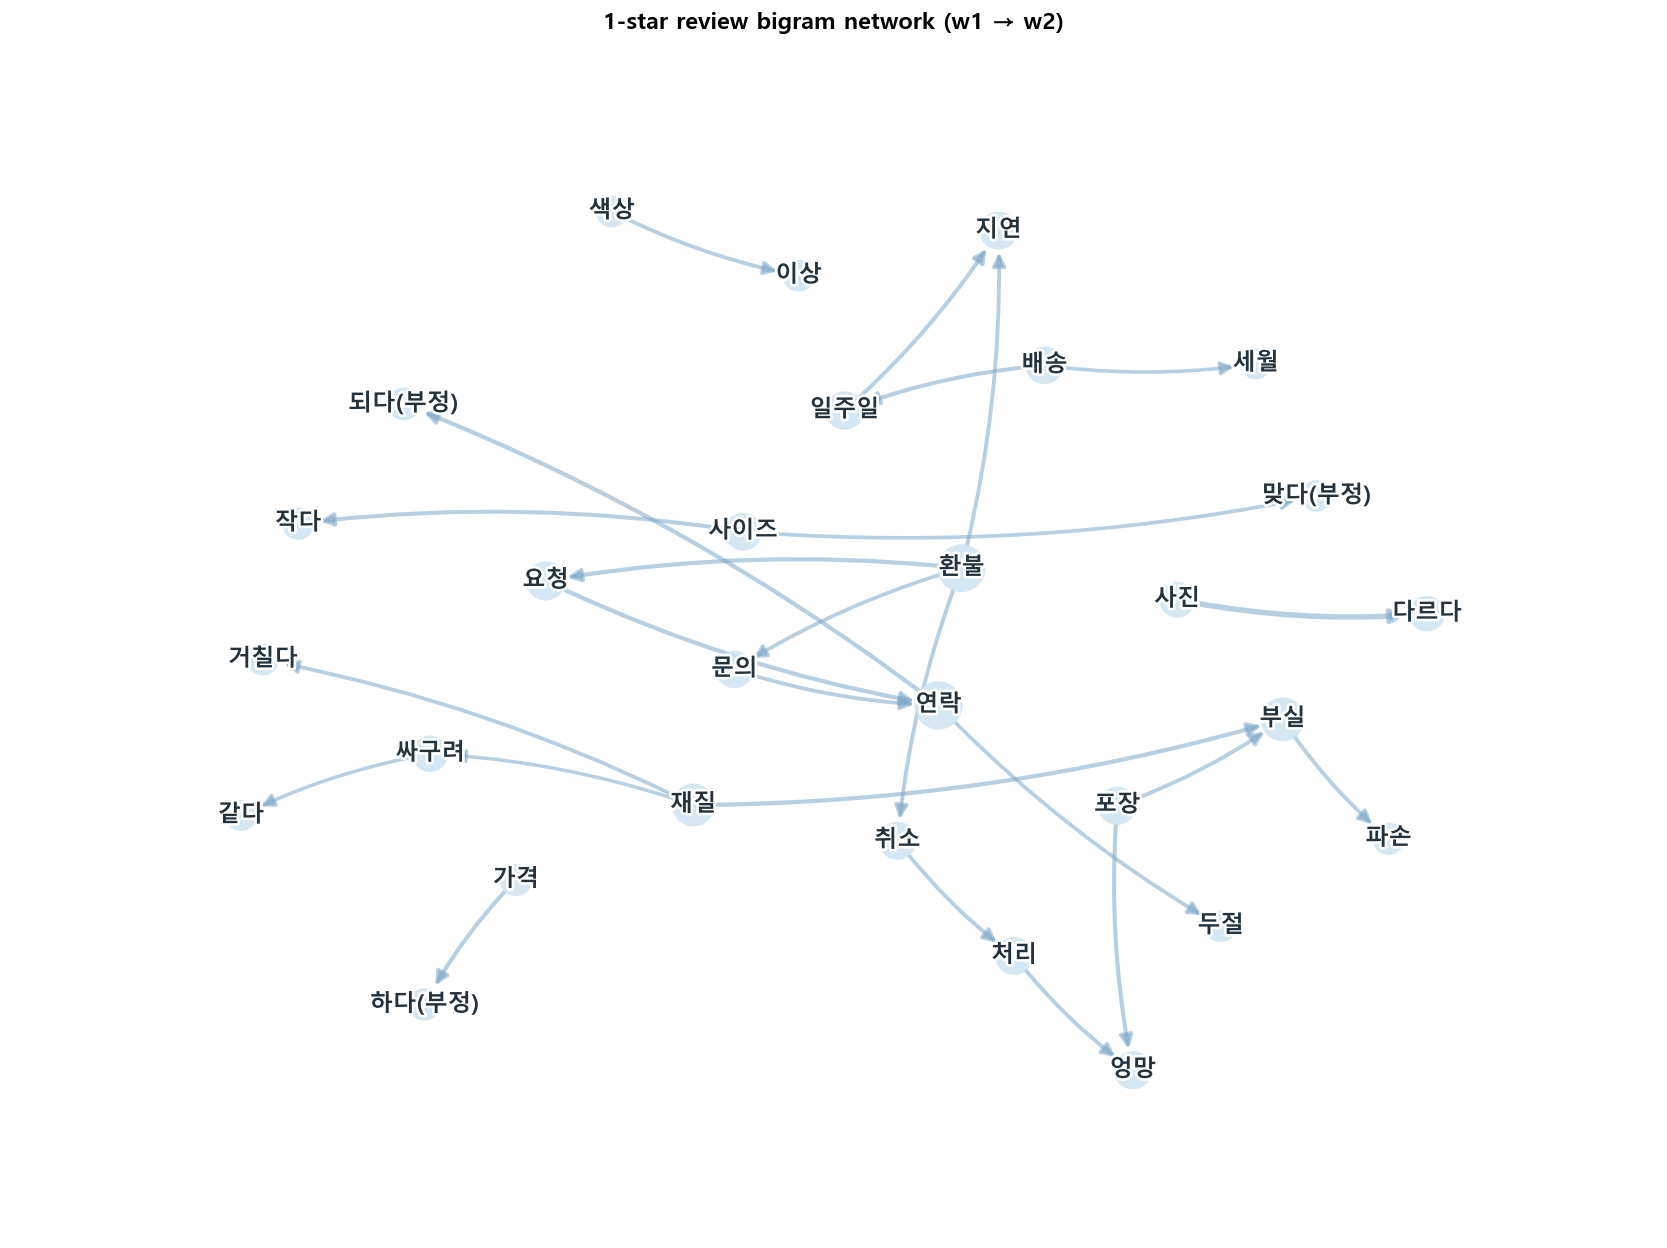

In [17]:
plt.figure(figsize=(14, 10.5), dpi=120)
nx.draw_networkx_nodes(BG, layout, node_color="#cfe3f3", node_size=node_size,
                       linewidths=0, alpha=0.85)
nx.draw_networkx_edges(
    BG, layout, node_size=node_size, edge_color="#7FA8C9",
    width=[0.7 + 2.6 * BG[u][v]["weight"] / wmax for u, v in BG.edges],
    alpha=0.55, arrows=True, arrowsize=16, arrowstyle="-|>",
    connectionstyle="arc3,rad=0.07", min_source_margin=8, min_target_margin=13,
)
# 흰 테두리(halo)로 글자 가독성 확보
for n, (x, y) in layout.items():
    plt.text(x, y, n, fontsize=14, fontweight="bold", ha="center", va="center",
             color="#23323d",
             path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])
plt.title("1-star review bigram network (w1 → w2)",
          fontsize=14, fontweight="bold", pad=10)
plt.margins(0.13)
plt.axis("off"); plt.tight_layout(); plt.show()

### 4.2. 동시출현 네트워크(Co-occurrence Network)

바이그램이 '바로 옆에 붙은' 두 단어만 본다면, 동시출현은 '같은 리뷰에 함께 나온' 단어 쌍을 봅니다.
연결 기준은 단순 동시출현 수가 아니라 **PMI**(우연보다 얼마나 더 자주 함께 나오나)로 잡아, 흔한
단어끼리 무조건 이어지는 '거미줄'을 피하고 진짜 연관만 남깁니다. 함께 묶이는 단어 무리(커뮤니티)를
색으로 구분하면, 1점 불만이 배송·환불(CS)·포장·재질·사이즈·디자인 같은 **덩어리**로 갈라지는 게
한눈에 보입니다.

In [18]:
import math
from itertools import combinations
from networkx.algorithms.community import greedy_modularity_communities

PALETTE = ["#E5564E", "#2F80B5", "#2E9E6B", "#E8913A",
           "#7C5CBF", "#1AA3A3", "#D4496A", "#8C8C8C"]
NET_DROP = {"하다", "되다", "있다", "같다", "보다"}  # 그림에서만 빼는 일반용언

def npmi_pairs(docs, word_df, min_word, min_pair):
    """리뷰별 단어 집합에서 NPMI가 양수인 단어 쌍을 점수순으로 돌려준다."""
    pair_df = Counter()
    for d in docs:
        for a, b in combinations(sorted(d), 2):  # 한 리뷰 안의 모든 단어 쌍
            pair_df[(a, b)] += 1
    N = len(docs)
    cand = []
    for (a, b), c in pair_df.items():
        if c < min_pair or word_df[a] < min_word or word_df[b] < min_word:
            continue  # 너무 드문 쌍/단어는 제외
        p_xy, p_x, p_y = c / N, word_df[a] / N, word_df[b] / N
        # 빈도 편향을 정규화 → '진짜 결합'만 남긴다
        npmi = math.log(p_xy / (p_x * p_y)) / (-math.log(p_xy))
        if npmi > 0:
            cand.append((npmi, a, b))
    return sorted(cand, reverse=True)

이 간선 집계를 이용해, 동시출현 네트워크를 만들고 커뮤니티 탐지로 단어 덩어리를 묶는 함수를 정의합니다.

In [19]:
def build_cooccurrence(texts, title, top_edges=40, min_word=22,
                       min_pair=12, exclude=None):
    """동시출현 쌍을 NPMI 상위 간선 네트워크로 집계하고, 커뮤니티로 묶는다.
    - exclude: 분석에서 빼고 싶은 단어 집합(예: 양쪽에 흔한 측면어).
    [내 데이터 적용] min_word·min_pair는 코퍼스 크기에 맞춰 조정합니다 — 리뷰가
    많을수록 키워 잡음을 거르고, 적을수록 낮춰 노드가 남게 합니다.
    top_edges는 그림에 표시할 연결 개수입니다."""
    exclude = (exclude or set()) | NET_DROP  # 일반용언 노이즈는 항상 제거
    docs = [set(tokenize(t)) - exclude for t in texts]  # 리뷰별 단어 집합
    word_df = Counter(w for d in docs for w in d)  # 단어가 등장한 리뷰 수
    G = nx.Graph()
    for pmi, a, b in npmi_pairs(docs, word_df, min_word, min_pair)[:top_edges]:
        G.add_edge(a, b, weight=pmi)

    # 커뮤니티 탐지 → 서로 촘촘히 연결된 단어들을 한 덩어리로 묶는다
    comms = list(greedy_modularity_communities(G, weight="weight"))
    print(f"[{title}] 단어 {G.number_of_nodes()}개 · "
          f"연결 {G.number_of_edges()}개 · 묶음 {len(comms)}개")
    for i, com in enumerate(comms):
        words = " ".join(sorted(com, key=lambda w: -word_df[w]))
        print(f"  묶음 {i+1}:", words)
    return G, word_df, comms

집계한 네트워크를 커뮤니티별 격자로 배치하는 함수를 정의합니다.

In [20]:
def community_layout(G, comms):
    """같은 덩어리는 같은 격자 칸에 배치한다 — 칸 안에서 스프링 배치 후,
    4.1 바이그램의 separate 를 그대로 재사용해 라벨 겹침을 정리한다."""
    cols = math.ceil(math.sqrt(len(comms)))
    DX, DY = 2.9, 2.7
    centers = {i: np.array([(i % cols) * DX, -(i // cols) * DY])
               for i in range(len(comms))}
    layout = {}
    for i, com in enumerate(comms):
        spread = 0.5 + 0.07 * len(com)  # 덩어리가 클수록 더 넓게 펼침
        if len(com) > 1:
            sp = nx.spring_layout(G.subgraph(com), k=0.9,
                                  iterations=200, seed=42)
        else:
            sp = {next(iter(com)): np.array([0.0, 0.0])}
        for n, p in sp.items():
            layout[n] = centers[i] + np.asarray(p, float) * spread
    return separate(layout, min_dist=0.40, iters=220)

이 좌표 위에 노드·연결·라벨을 실제로 그리는 함수를 정의합니다.

In [21]:
def draw_cooccurrence(G, word_df, comms, title):
    ncolor = {n: PALETTE[i % len(PALETTE)]
              for i, com in enumerate(comms) for n in com}
    fmax = max(word_df[n] for n in G.nodes)
    node_size = [220 + 1000 * word_df[n] / fmax for n in G.nodes]
    wmax = max(d["weight"] for *_, d in G.edges(data=True))
    e_width = [1.0 + 3.0 * G[u][v]["weight"] / wmax for u, v in G.edges]
    layout = community_layout(G, comms)

    fig, ax = plt.subplots(figsize=(12, 7.6), dpi=120)
    ax.set_axis_off()
    nx.draw_networkx_edges(G, layout, ax=ax, edge_color="#c4ccd3", alpha=0.7,
                           width=e_width)
    nx.draw_networkx_nodes(G, layout, ax=ax, node_size=node_size, linewidths=0,
                           node_color=[ncolor[n] for n in G.nodes], alpha=0.9)
    for n, (x, y) in layout.items():
        ax.text(x, y, n, fontsize=14, fontweight="bold", ha="center",
                va="center", color="#1f2a31",
                path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])
    xs = [p[0] for p in layout.values()]; ys = [p[1] for p in layout.values()]
    ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
    ax.set_ylim(min(ys) - 0.55, max(ys) + 0.55)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.94, bottom=0.02)
    plt.show()

두 함수를 묶은 cooccurrence_network로 1점 리뷰의 네트워크를 그려 봅니다.

[1-star co-occurrence network — PMI, grouped by cluster] 단어 31개 · 연결 40개 · 묶음 7개
  묶음 1: 재질 포장 부실 파손 거칠다 싸구려
  묶음 2: 환불 연락 되다(부정) 요청 문의 두절
  묶음 3: 배송 지연 일주일 세월 느리다
  묶음 4: 디자인 색상 다르다 사진 이상
  묶음 5: 엉망 취소 처리
  묶음 6: 가격 하다(부정) 비싸다
  묶음 7: 사이즈 작다 맞다(부정)


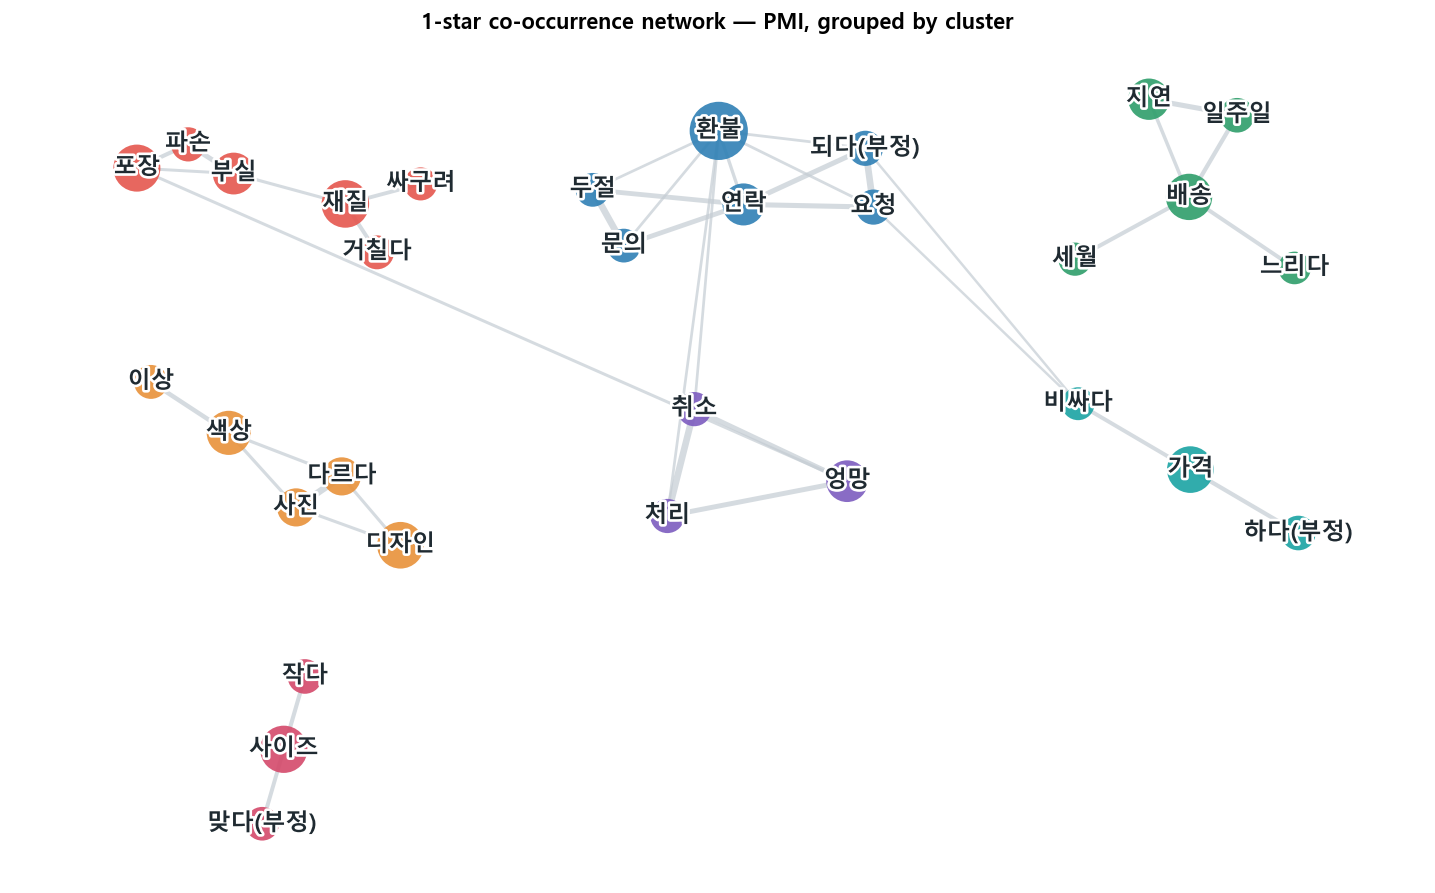

In [22]:
def cooccurrence_network(texts, title, **kwargs):
    """집계(build)와 그리기(draw)를 한 번에 — 실습 7의 5점 네트워크도 그대로 쓴다."""
    G, word_df, comms = build_cooccurrence(texts, title, **kwargs)
    draw_cooccurrence(G, word_df, comms, title)
    return G

_ = cooccurrence_network(
    neg, "1-star co-occurrence network — PMI, grouped by cluster")

## 실습 5. 텍스트 주제 및 의미 분석

개별 단어를 넘어 리뷰 전체를 관통하는 '주제(topic)'와 '의미' 단위로 한 차원 더 분석합니다.

### 5.1. 토픽 모델링(LDA)

수만 건의 리뷰에 어떤 주제가 잠재돼 있는지 자동으로 묶습니다. 각 토픽의 상위 단어로 주제를 읽고
(라벨링은 사람의 몫), 더 나아가 각 리뷰가 어느 토픽에 얼마나 속하는지 비중까지 숫자로 계산합니다.
바로 이 '문서별 토픽 비중'이, 네트워크가 하지 못하던 '정성적 주제를 셀 수 있는 숫자로 바꾸는' 일입니다.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# LDA는 TF-IDF가 아니라 '단어 빈도(raw count)'를 입력으로 받는다.
# max_df=0.5 : 문서 절반 넘게 나오는 너무 흔한 단어 제외
# min_df=10  : 10개 미만 문서에만 나오는 희귀어 제외
cv = CountVectorizer(max_df=0.5, min_df=10, token_pattern=r"(?u)[^\s]+")
dtm = cv.fit_transform(reviews["joined"])  # 위에서 만든 형태소 문서 재사용
# [내 데이터 적용] 토픽 수(n_components)는 정답이 없습니다. 5~15를 바꿔 보며
#   해석하기 좋은 값을 고르고, 리뷰 수가 적으면 max_df/min_df도 낮춰 줍니다.
lda = LatentDirichletAllocation(n_components=5, random_state=2)
doc_topic = lda.fit_transform(dtm)  # 각 리뷰의 토픽 비중 (리뷰 수 × 5)

# 각 토픽의 상위 단어 8개씩 출력
terms = np.array(cv.get_feature_names_out())
for k, comp in enumerate(lda.components_):
    print(f"토픽 {k}:", " ".join(terms[comp.argsort()[::-1][:8]]))

토픽 0: 편하다 휴대 야외 캠핑 유용 사이즈 좋다 배송
토픽 1: 원룸 공간 자취 차지 만족 사다 사이즈 좋다
토픽 2: 디자인 다르다 사진 환불 가격 색상 재질 배송
토픽 3: 환불 포장 사이즈 재질 배송 엉망 지연 부실
토픽 4: 키우다 반려동물 청소 강아지 추천 붙다(부정) 위생 배송


각 토픽의 상위 단어를 막대로 그려, 토픽 라벨링의 근거를 눈으로 확인합니다.

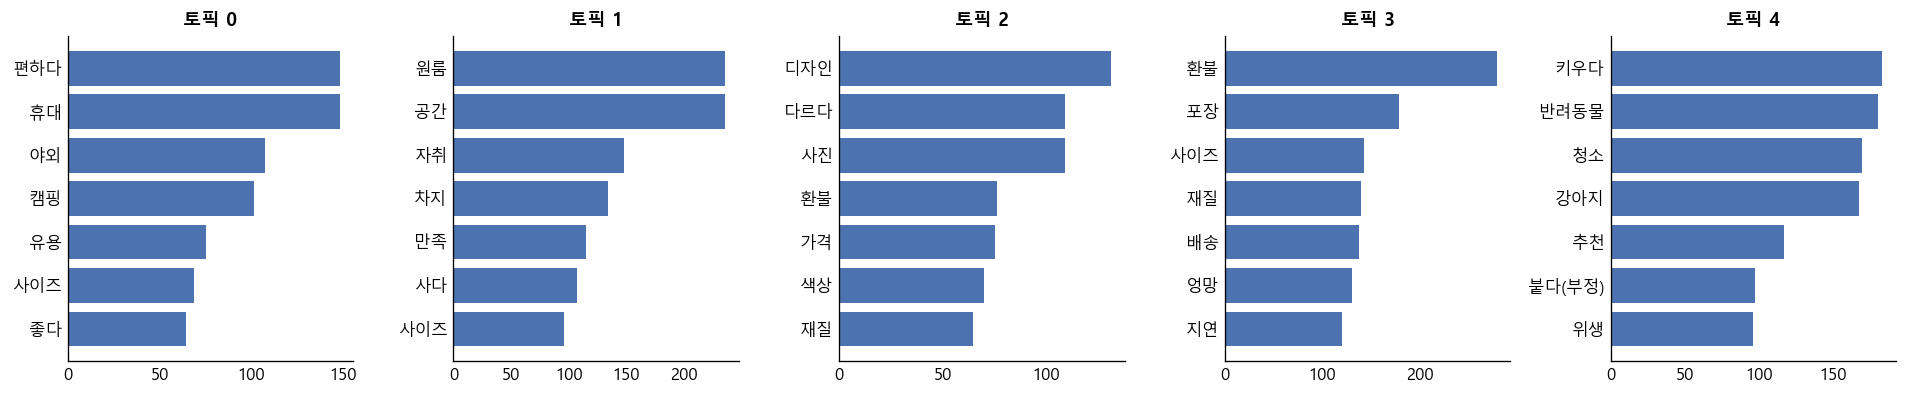

In [24]:
_n = lda.n_components
_fig, _axes = plt.subplots(1, _n, figsize=(3.2 * _n, 3.4), dpi=120)
for k, ax in enumerate(_axes):
    comp = lda.components_[k]
    idx  = comp.argsort()[::-1][:7]
    ax.barh(range(len(idx)), comp[idx][::-1], color="#4C72B0")
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels(terms[idx][::-1], fontsize=10)
    ax.set_title(f"토픽 {k}", fontsize=11, fontweight="bold")
    ax.tick_params(length=0)
    for _s in ["top", "right"]:
        ax.spines[_s].set_visible(False)
plt.tight_layout(); plt.show()

각 리뷰가 어느 토픽에 얼마나 속하는지(`doc_topic`)도 확인할 수 있습니다. 아래 코드는 토픽 수나 seed를 바꾸면 토픽 순서가 달라질 수 있어, 각 토픽의 상위 2개 단어로 임시 라벨을 자동 생성해 열 이름으로 씁니다. 한 주제에 집중된
리뷰는 특정 토픽 비중이 90%를 넘고, 여러 이야기가 섞인 리뷰는 두 토픽에 비중이 나뉩니다.

In [25]:
# 토픽 비중(doc_topic)에 상위 2개 단어로 만든 임시 라벨을 열 이름으로 단다.
# (최종 라벨은 위 상위어를 사람이 읽고 손으로 다듬으세요)
_terms = np.array(cv.get_feature_names_out())
TOPIC_LABELS = ["·".join(_terms[c.argsort()[::-1][:2]])
                for c in lda.components_]
dt = pd.DataFrame(doc_topic, columns=TOPIC_LABELS)

def topic_share(i):
    """리뷰 i의 토픽 비중을 비중 높은 순으로 '라벨 NN%' 문자열로 정리한다."""
    s = dt.iloc[i].sort_values(ascending=False)
    return " · ".join(f"{lab} {p*100:.0f}%"
                      for lab, p in s.items() if p >= 0.1)

# 한 주제에 집중된 리뷰 2건 + 여러 주제가 섞인 리뷰 1건을 뽑아 비교한다
i_focus1 = doc_topic[:, 4].argmax()  # '키우다·반려동물' 비중 최고
i_focus2 = doc_topic[:, 2].argmax()  # '디자인·다르다' 비중 최고
i_mixed = np.sort(doc_topic, axis=1)[:, -2].argmax()  # 2등 비중이 가장 큰 리뷰

pd.DataFrame({
    "리뷰": [reviews["text"].iloc[i][:40] + "…"
            for i in (i_focus1, i_focus2, i_mixed)],
    "토픽 비중": [topic_share(i) for i in (i_focus1, i_focus2, i_mixed)],
})

,리뷰,토픽 비중
0,강아지 털 청소가 쉬워서 반려동물 키우며 입소문 났어요 색상이 화면과 똑…,키우다·반려동물 96%
1,색상이 사진과 다르고 디자인이 사진과 다르고 가격값을 못 하고 환불 요청…,디자인·다르다 94%
2,가성비가 훌륭하고 재구매 의사 있어요 색상이 선명하고 원룸 자취 공간에 …,원룸·공간 49% · 편하다·휴대 48%


### 토픽 시계열 — 주제는 시간에 따라 뜨고 진다

토픽 모델링의 또 다른 쓸모는 **시간축**입니다. 각 리뷰의 토픽 비중(`doc_topic`)을 작성일과 묶어 주차별로 평균 내면, 어떤 주제가 언제 떠오르고 가라앉는지가 보입니다. 아래 그림에서는 기획 의도였던 **자취·공간**이 초반에 몰려 있고, 뒤늦게 발견된 **차박·캠핑**과 **반려동물** 쓰임새가 시간이 갈수록 비중을 넓혀 갑니다 — 실습 7에서 이야기할 '발견의 확산'이 시간축에서도 그대로 드러나는 셈이죠.

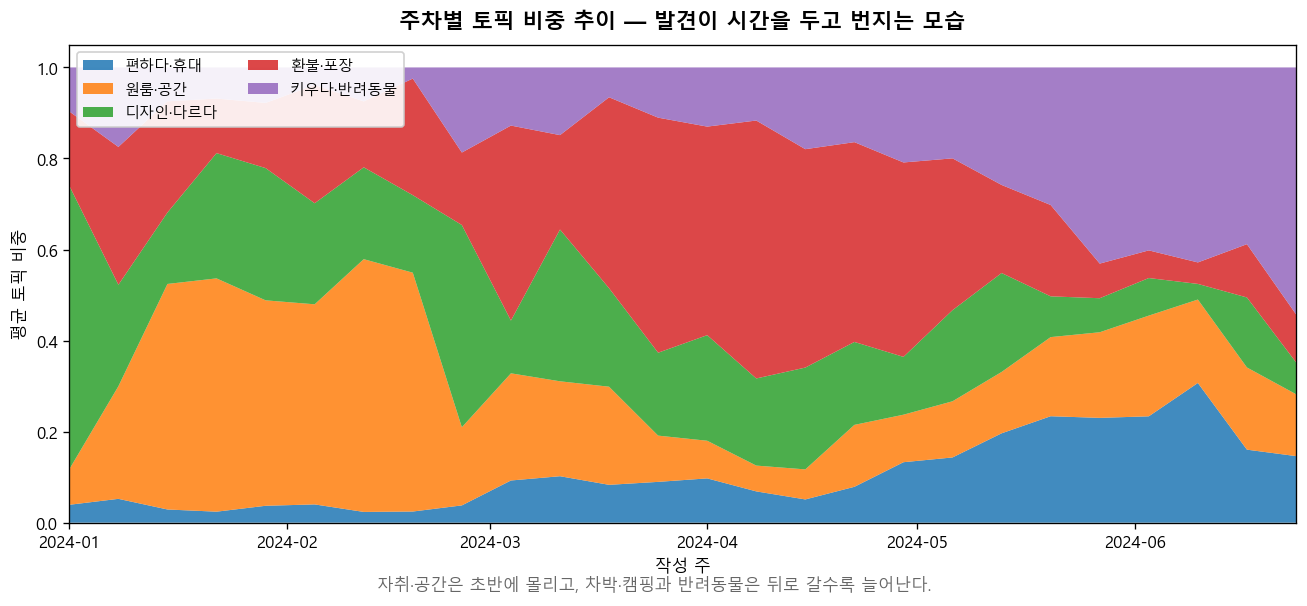

In [26]:
# [내 데이터 적용] created_at 같은 날짜 컬럼이 있을 때만 동작합니다.
reviews["created_at"] = pd.to_datetime(reviews["created_at"])
week = reviews["created_at"].dt.to_period("W").dt.start_time
weekly = pd.DataFrame(doc_topic, columns=TOPIC_LABELS)
weekly["week"] = week.values
weekly = weekly.groupby("week")[TOPIC_LABELS].mean()

fig, ax = plt.subplots(figsize=(11, 5), dpi=120)
ax.stackplot(weekly.index, *[weekly[c] for c in TOPIC_LABELS],
             labels=TOPIC_LABELS, alpha=0.85)
ax.legend(loc="upper left", fontsize=9, ncol=2, framealpha=0.9)
ax.set_title("주차별 토픽 비중 추이 — 발견이 시간을 두고 번지는 모습",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("작성 주"); ax.set_ylabel("평균 토픽 비중")
ax.margins(x=0)
fig.text(0.5, 0.005, "자취·공간은 초반에 몰리고, "
         "차박·캠핑과 반려동물은 뒤로 갈수록 늘어난다.",
         ha="center", fontsize=10, color="#666")
plt.tight_layout(); plt.show()

### 감성 분석 · 임베딩 · LLM

이 외에도 정성 데이터의 맥락을 분석하는 방법으로 **감성 분석**(특히 측면 기반 ABSA),
**임베딩**(겉모습이 달라도 뜻이 가까운 말을 묶음), **LLM 기반 분석**(사람처럼 읽고 분류·요약)이
있습니다. 각각 별도의 책으로도 다룰 만큼 방대한 주제라 이 노트북에서는 코드 실습을 생략합니다.
임베딩 군집화(`sentence-transformers`)나 LLM 호출은 무거운 의존성·API 키가 필요하기도 합니다.
관심이 있다면 책 본문의 키워드를 실마리 삼아 별도 자료로 공부해 보세요. (아래 실습 6의 '대표 리뷰'는
임베딩 군집 대신 LDA 토픽 비중으로 같은 효과를 냅니다.)

## 실습 6. 원문에 포함된 구체적인 맥락 확인

추상화된 숫자에서 멈추지 않고 실제 문장으로 내려옵니다. 키워드 좌우 문맥(KWIC)과, LDA 토픽
비중이 가장 높은 대표 리뷰를 직접 읽어 신호가 진짜인지 확인하고, 숫자가 뭉뚱그린 뉘앙스를 되살립니다.
(KWIC은 키워드를 글자 그대로 찾으므로 '환불'은 잡아도 뜻이 비슷한 '반품'은 따로 검색해야 합니다.)

In [27]:
def kwic(texts, keyword, width=20, n=8):
    """keyword가 등장한 리뷰를 좌우 문맥과 함께 보여 준다."""
    hits = []
    for t in texts:
        s = str(t)
        i = s.find(keyword)
        if i >= 0:
            left = s[max(0, i - width):i]
            right = s[i + len(keyword): i + len(keyword) + width]
            hits.append(f"…{left}[{keyword}]{right}…")
        if len(hits) >= n:
            break
    return hits

# [내 데이터 적용] "환불" 대신 내 분석에서 궁금한 키워드를 넣습니다.
#   (여러 개를 돌려 봐도 좋습니다)
print("[KWIC] '환불' 문맥")
for line in kwic(neg, "환불"):
    print("  ", line)

[KWIC] '환불' 문맥
   …재질이 거칠고 가격이 비싼데 별로고 [환불] 요청에 연락이 안 되고 별점이 아까…
   …색상이 이상하고 재질이 부실하고 [환불] 문의에 연락이 두절이고 두 번 다시…
   …[환불] 취소 처리가 엉망이고 배송이 느리고…
   …[환불] 문의에 연락이 두절이고 사이즈가 작…
   …배송이 느리고 [환불]이 계속 지연되고 가격이 비싼데 별로…
   …색상이 칙칙하고 [환불]이 계속 지연되고 포장이 부실해서 파…
   …사이즈가 헐렁하고 [환불] 요청에 연락이 안 되고 재질이 부실…
   …이 별로고 포장이 부실해서 파손됐고 [환불] 받고 싶네요ㅠㅠ…


이어서 LDA 토픽별로 비중이 가장 높은 대표 리뷰를 뽑아 표로 정리합니다.

In [28]:
texts = reviews["text"].to_numpy()
rep_rows = []
for k in range(lda.n_components):
    i = doc_topic[:, k].argmax()  # 토픽 k 비중이 가장 높은 리뷰
    rep_rows.append({
        "토픽": f"토픽 {k}",
        "비중": f"{doc_topic[i, k] * 100:.0f}%",
        "대표 리뷰": texts[i],
    })

rep = pd.DataFrame(rep_rows)
rep.style.hide(axis="index") \
    .set_caption("[LDA 토픽별 대표 리뷰] 토픽 비중이 가장 높은 리뷰") \
    .set_properties(**{"text-align": "left"})

토픽,비중,대표 리뷰
토픽 0,95%,가격이 만족스럽고 캠핑 다닐 때 배낭에 넣어도 가벼워 부담 없어요 강력 추천합니다 배송이 하루 만에 오고 색상이 화면과 똑같고...
토픽 1,96%,혼자 사는 원룸이라 공간 차지 안 하는 크기가 마음에 들어요 배송이 신속하고 색상이 마음에 들고 재구매 의사 있어요 사이즈가 딱 맞고ㅠㅠ
토픽 2,94%,색상이 사진과 다르고 디자인이 사진과 다르고 가격값을 못 하고 환불 요청에 연락이 안 되고 완전 실망이에요ㅠㅠ
토픽 3,94%,환불 문의에 연락이 두절이고 재질이 싸구려 같고 포장이 부실해서 파손됐고 사이즈가 작고 두 번 다시 안 사요
토픽 4,96%,강아지 털 청소가 쉬워서 반려동물 키우며 입소문 났어요 색상이 화면과 똑같고 가격이 합리적이고 재구매 의사 있어요 배송이 하루 만에 오고 원래 집에서 쓰려고 샀는데 가벼워서 차박 갈 때 챙겨 가요


## 실습 7. 긍정 리뷰가 알려주는 것 — 미처 몰랐던 쓰임새와 고객

불만은 배송·환불 같은 몇 개의 운영 이슈로 납작하게 수렴합니다. 반면 만족은 저마다의 삶의 맥락에서
나오기에 훨씬 입체적입니다. 똑같은 동시출현 네트워크를 5점 리뷰에 그려 보면, '쓰임새(use case)'와
'고객군(segment)' 덩어리가 드러납니다 — 원룸용으로 기획한 제품이 캠핑·차박, 반려동물 가구로도
쓰이는 것처럼, 제품을 기획할 땐 미처 생각하지 못했던 경쟁력의 단서입니다.
불만은 납작하고, 만족은 입체적이라는 점을 기억해 주세요. 두 집단 공통의 측면어·상투어(`flat_words`)를 잘
걷어내면 결과가 더 명확해집니다.

[5-star co-occurrence network — use cases & segments] 단어 24개 · 연결 48개 · 묶음 3개
  묶음 1: 원룸 공간 자취 차지 크기 시작 하다(부정) 혼자 자취방
  묶음 2: 휴대 편하다 야외 차박 캠핑 챙기다 유용 배낭
  묶음 3: 반려동물 청소 강아지 붙다(부정) 위생 간편하다 입소문


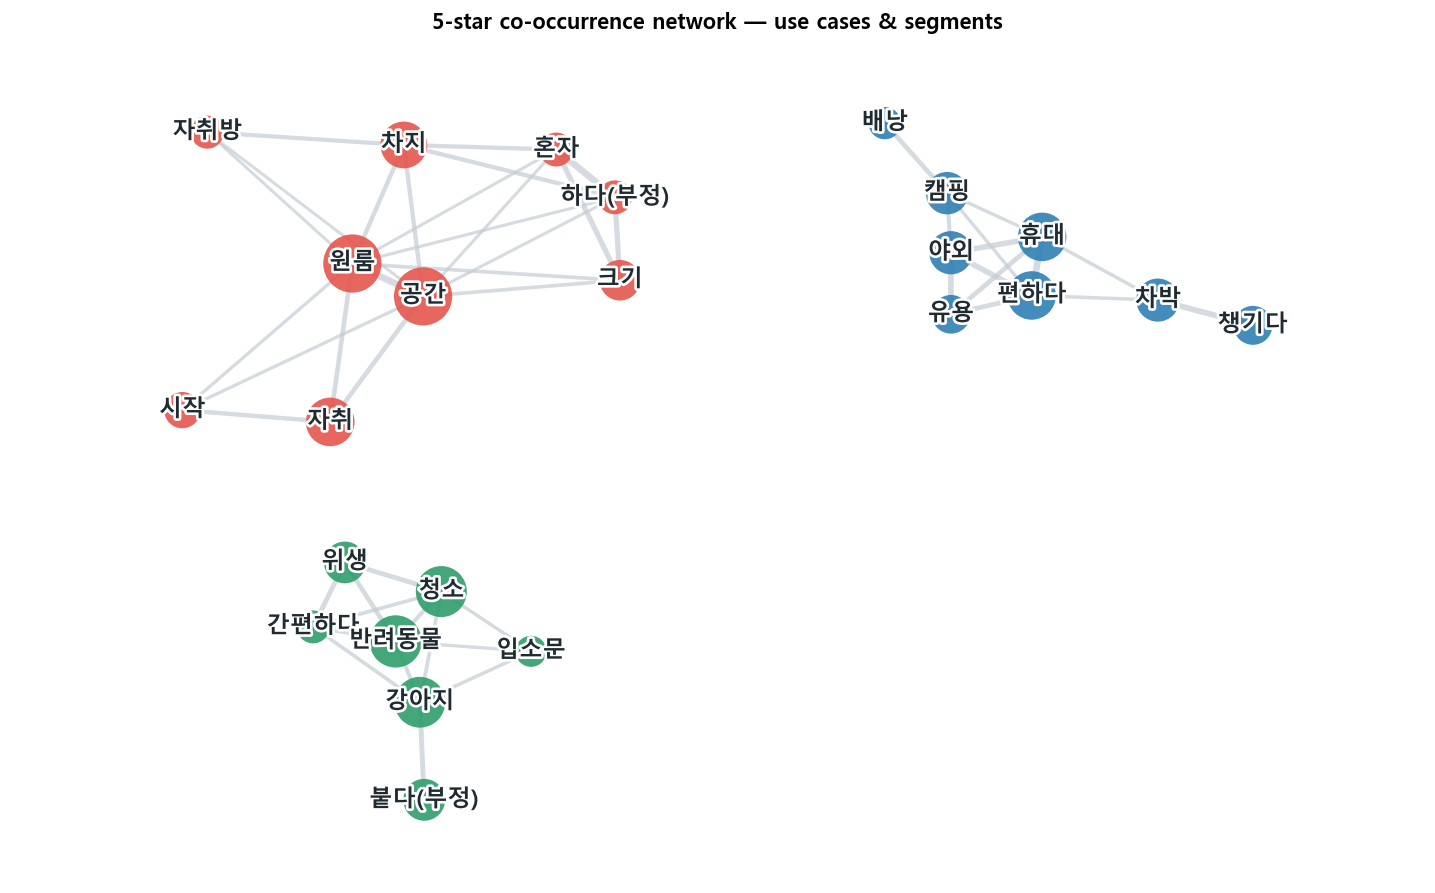

In [29]:
# 측면어·일반 만족어와 일반 동사 노이즈는 빼고 '맥락' 단어만 남긴다
# [내 데이터 적용] flat_words에는 두 집단 공통으로 흔한 측면어/상투어를 넣고,
#   내 카테고리에 맞게 교체합니다(화장품: 향·발색·지속력, 의류: 핏·소재·색감).
flat_words = {
    # 측면(중립 명사)
    "배송", "가격", "디자인", "색상", "사이즈", "재질", "포장",
    # 측면별 긍정 의견어
    "빠르다", "신속", "합리", "만족", "가성비", "훌륭", "예쁘다", "세련",
    "고급", "화면", "똑같다", "선명", "마음", "정사이즈", "넉넉", "튼튼",
    "부드럽다", "꼼꼼", "깔끔", "정성",
    # 마무리 상투어
    "전체", "재구매", "의사", "강력", "추천", "기대", "이상", "좋다",
    # 맥락을 가리지 않는 일반 동사·잡음
    "쓰다", "가다", "주다", "사다", "드리다", "키우다", "넣다", "두다",
    "들다", "있다", "하다", "되다", "보다", "다니다", "붙다", "맞다",
    "없다", "부담", "적당", "좋아하다", "걱정", "원래", "분", "나다",
    "같다", "하루", "오다", "신속",
}
_ = cooccurrence_network(pos,
                         "5-star co-occurrence network — use cases & segments",
                         top_edges=48, min_word=20, exclude=flat_words)

## 마치며

좋은 정성 분석은 추상화와 구체화를 오갑니다. 수만 건의 문장을 빈도·가중치·네트워크·토픽으로
추상화해 큰 그림을 잡고, 그 그림이 가리키는 곳의 실제 문장으로 내려와 확인하는 것이죠. 이
노트북은 그 과정을 빈도 → 가중치 → 연관성·네트워크 → 주제·의미 → 원문 회귀 → 긍정 리뷰의
발견 순서로 따라가 봤습니다.

> **여기서 다루지 않은 것** — 책 본문 4.2의 감성 분석·임베딩·LLM 기반 분석은 무거운 의존성이나
> API 키가 필요해 이 노트북에서는 개념 소개로 갈음했습니다. 원문 회귀(실습 6)는 임베딩 군집 대신
> LDA 토픽 비중으로 대표 리뷰를 뽑아 보여 주었습니다.